## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolínea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué rendimiento presentan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# estadísticas y modelos de series temporales
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima.arima import ARIMA, auto_arima

# métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error

# modelos supervisados
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 1. Carga datos y representa la serie

In [15]:
# cargo el CSV de pasajeros aéreos mensuales (1949–1960)
df = pd.read_csv('data/AirPassengers.csv', parse_dates=['date'], index_col='date')
print(df.columns)
df.head()


Index(['value'], dtype='object')


,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [17]:
df.shape


(144, 1)

In [18]:
print(f'\nRango de fechas: {df.index.min()} → {df.index.max()}')


Rango de fechas: 1949-01-01 00:00:00 → 1960-12-01 00:00:00


In [19]:
print(f'Estadísticas básicas:\n{df.describe()}')

Estadísticas básicas:
            value
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


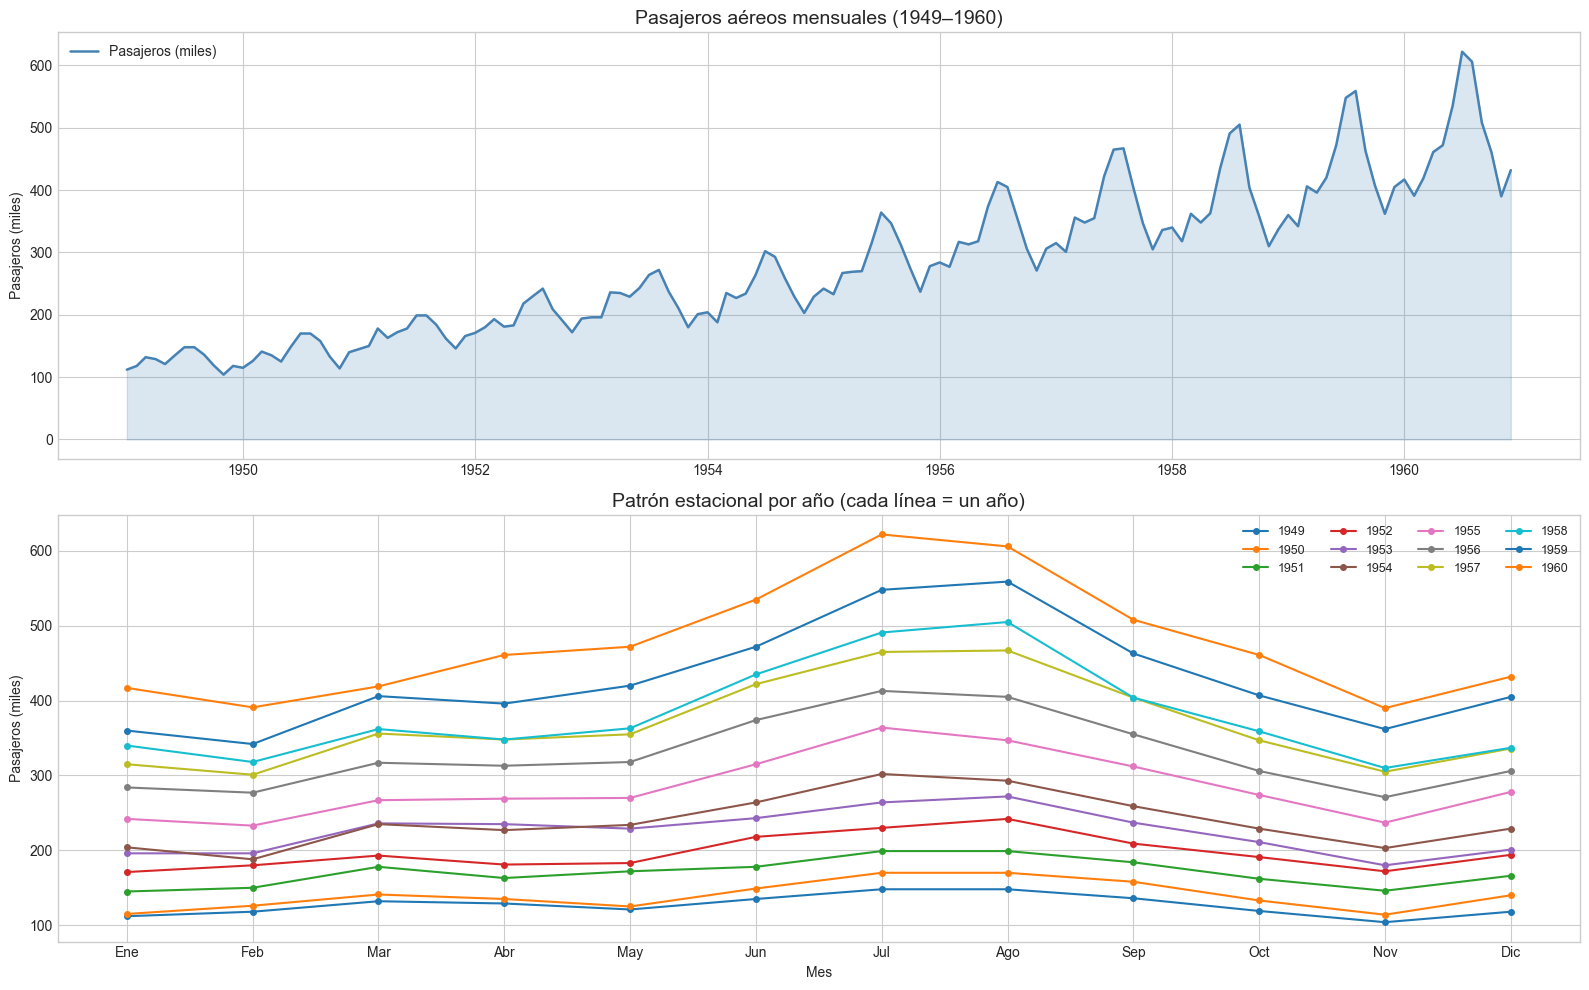


Observaciones:
────────────────────────────────────────────────────────────
✔ TENDENCIA CRECIENTE muy clara: de ~130k pasajeros en 1949
  a ~430k en 1960.

✔ ESTACIONALIDAD ANUAL: cada año se repite el mismo patrón.
  Pico en JULIO-AGOSTO (verano, vacaciones) y caída en
  noviembre-febrero. → Período estacional = 12 meses.

✔ VARIANZA CRECIENTE: las oscilaciones se amplían a medida
  que aumenta el nivel → modelo multiplicativo.
────────────────────────────────────────────────────────────



In [20]:
# visualización de la serie
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# serie completa
axes[0].plot(df.index, df['value'], color='steelblue', linewidth=1.8, label='Pasajeros (miles)')
axes[0].fill_between(df.index, df['value'], alpha=0.2, color='steelblue')
axes[0].set_title('Pasajeros aéreos mensuales (1949–1960)', fontsize=14)
axes[0].set_ylabel('Pasajeros (miles)')
axes[0].legend()

# gráfica por año para ver la estacionalidad
df_plot = df.copy()
df_plot['year']  = df_plot.index.year
df_plot['month'] = df_plot.index.month

for year in df_plot['year'].unique():
    subset = df_plot[df_plot['year'] == year]
    axes[1].plot(subset['month'], subset['value'], marker='o', markersize=4,
                 linewidth=1.5, label=str(year))

axes[1].set_title('Patrón estacional por año (cada línea = un año)', fontsize=14)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Pasajeros (miles)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
axes[1].legend(ncol=4, fontsize=9)

plt.tight_layout()
plt.show()

print("""
Observaciones:
────────────────────────────────────────────────────────────
✔ TENDENCIA CRECIENTE muy clara: de ~130k pasajeros en 1949
  a ~430k en 1960.

✔ ESTACIONALIDAD ANUAL: cada año se repite el mismo patrón.
  Pico en JULIO-AGOSTO (verano, vacaciones) y caída en
  noviembre-febrero. → Período estacional = 12 meses.

✔ VARIANZA CRECIENTE: las oscilaciones se amplían a medida
  que aumenta el nivel → modelo multiplicativo.
────────────────────────────────────────────────────────────
""")

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior

In [ ]:
# representamos la serie junto a su media móvil usando la ventana del período estacional (12 meses)
# esto suaviza los picos estacionales y deja visible la tendencia.

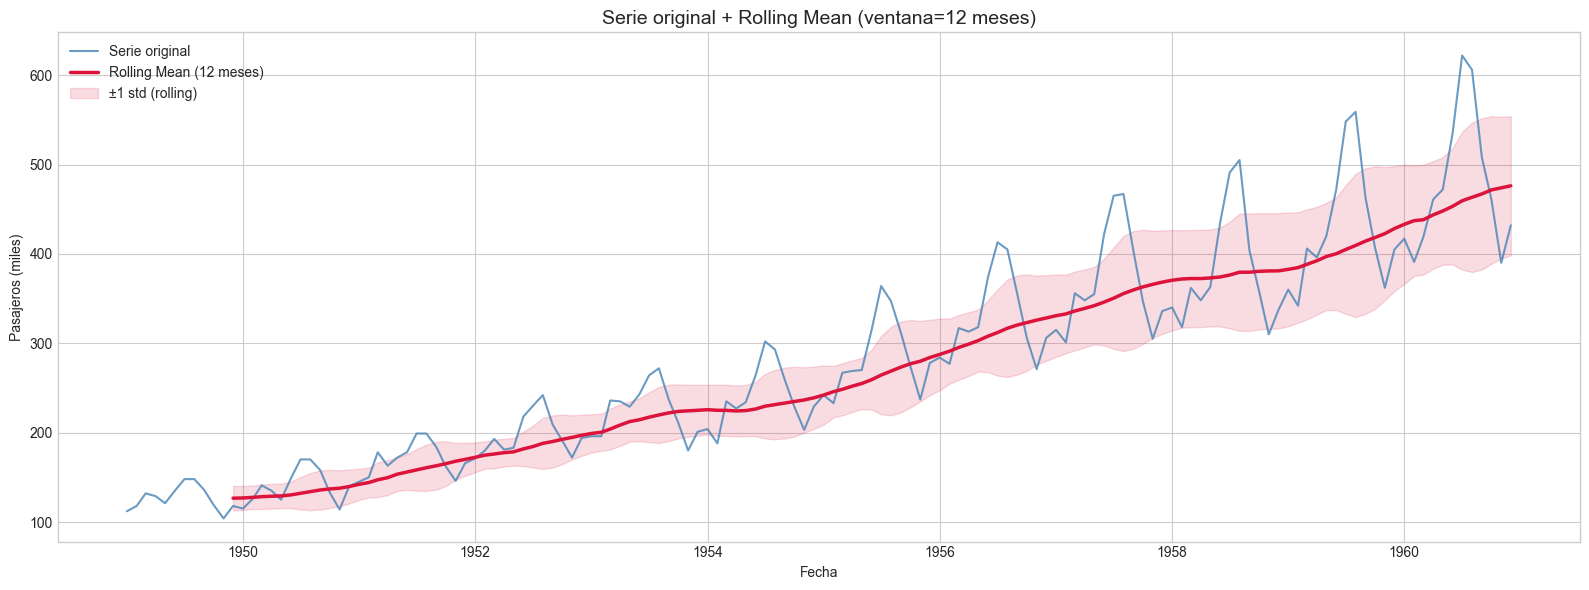


Interpretación:
• La línea roja (rolling mean) elimina el ruido estacional y deja
  visible únicamente la tendencia creciente.
• La banda gris muestra cómo crece también la desviación típica,
  confirmando que la varianza no es constante → serie NO estacionaria.
• Cuando la media y la std son crecientes, el test ADF seguramente
  confirmará que la serie no es estacionaria.



In [21]:
# el período estacional es 12 meses → ventana de la rolling window = 12
seasonality = 12

# rolling(12).mean() calcula la media de los últimos 12 valores en cada punto.
# center=False → usa los 12 valores anteriores (más realista para forecasting)
rolling_mean = df['value'].rolling(window=seasonality).mean()
rolling_std  = df['value'].rolling(window=seasonality).std()

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df.index, df['value'],
        color='steelblue', linewidth=1.5, label='Serie original', alpha=0.8)
ax.plot(df.index, rolling_mean,
        color='crimson', linewidth=2.5, label=f'Rolling Mean ({seasonality} meses)')

# banda de ±1 std para visualizar la variabilidad
ax.fill_between(df.index,
                rolling_mean - rolling_std,
                rolling_mean + rolling_std,
                color='crimson', alpha=0.15, label='±1 std (rolling)')

ax.set_title(f'Serie original + Rolling Mean (ventana={seasonality} meses)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Pasajeros (miles)')
ax.legend()
plt.tight_layout()
plt.show()

print("""
Interpretación:
• La línea roja (rolling mean) elimina el ruido estacional y deja
  visible únicamente la tendencia creciente.
• La banda gris muestra cómo crece también la desviación típica,
  confirmando que la varianza no es constante → serie NO estacionaria.
• Cuando la media y la std son crecientes, el test ADF seguramente
  confirmará que la serie no es estacionaria.
""")

## 3. Comprueba de manera estadística si la serie es o no estacionaria.

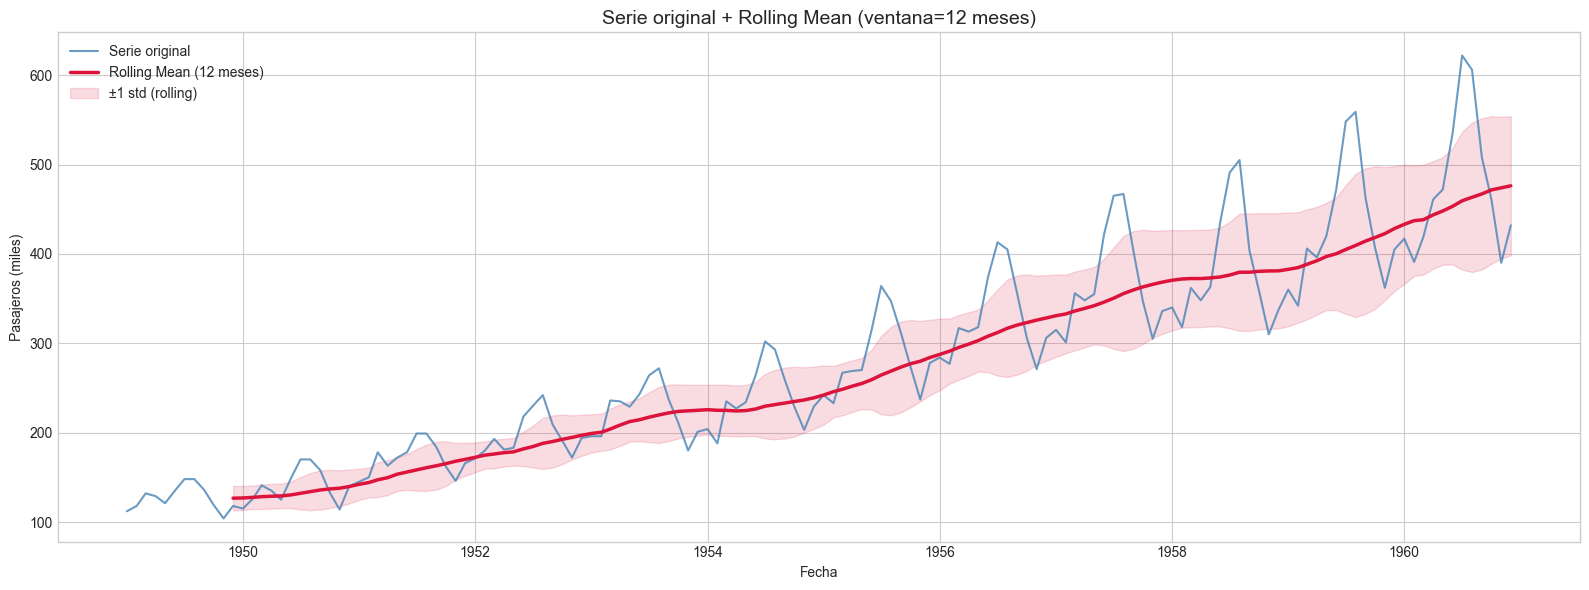


Interpretación:
• La línea roja (rolling mean) elimina el ruido estacional y deja
  visible únicamente la tendencia creciente.
• La banda gris muestra cómo crece también la desviación típica,
  confirmando que la varianza no es constante → serie NO estacionaria.
• Cuando la media y la std son crecientes, el test ADF seguramente
  confirmará que la serie no es estacionaria.



In [23]:
# el período estacional es 12 meses → ventana de la rolling window = 12
seasonality = 12

# rolling(12).mean() calcula la media de los últimos 12 valores en cada punto.
# center=False → usa los 12 valores anteriores (más realista para forecasting)
rolling_mean = df['value'].rolling(window=seasonality).mean()
rolling_std  = df['value'].rolling(window=seasonality).std()

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df.index, df['value'],
        color='steelblue', linewidth=1.5, label='Serie original', alpha=0.8)
ax.plot(df.index, rolling_mean,
        color='crimson', linewidth=2.5, label=f'Rolling Mean ({seasonality} meses)')

# bnda de ±1 std para visualizar la variabilidad
ax.fill_between(df.index,
                rolling_mean - rolling_std,
                rolling_mean + rolling_std,
                color='crimson', alpha=0.15, label='±1 std (rolling)')

ax.set_title(f'Serie original + Rolling Mean (ventana={seasonality} meses)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Pasajeros (miles)')
ax.legend()
plt.tight_layout()
plt.show()

print("""
Interpretación:
• La línea roja (rolling mean) elimina el ruido estacional y deja
  visible únicamente la tendencia creciente.
• La banda gris muestra cómo crece también la desviación típica,
  confirmando que la varianza no es constante → serie NO estacionaria.
• Cuando la media y la std son crecientes, el test ADF seguramente
  confirmará que la serie no es estacionaria.
""")

## 4. Aplica una transformación logarítmica

In [ ]:
# la transformación `log` tiene dos efectos beneficiosos:
#   Estabiliza la varianza creciente (heterocedasticidad).
#   Convierte relaciones multiplicativas en aditivas, facilitando la diferenciación.

# tras el forecasting habrá que invertir la transformación con `np.exp()`.

In [ ]:
from statsmodels.tsa.stattools import adfuller

def test_adf(series, nombre='Serie'):
    """
    Aplica el test ADF a una serie temporal y muestra el p-valor.
    Devuelve el p-valor para uso posterior.
    """
    serie = series.dropna()
    resultado = adfuller(serie)
    pvalor = resultado[1]

    print(f"\nADF — {nombre}")
    print(f"  Estadístico ADF: {resultado[0]:.4f}")
    print(f"  p-valor:         {pvalor:.4f}")
    print("  → Estacionaria ✓" if pvalor < 0.05 else "  → No estacionaria ✗")

    return pvalor

# Definimos la función test_adf() para aplicar el test de Dickey–Fuller aumentado (ADF)
# de forma cómoda y consistente en el notebook.
#
# ¿Para qué sirve?
# • El test ADF evalúa si una serie temporal es estacionaria (p-valor < 0.05).
# • La estacionariedad es un requisito clave para modelos ARIMA/SARIMA.
# • Pandas/statsmodels devuelven muchos valores; esta función resume lo importante.
#
# ¿Por qué la creamos?
# • Para evitar repetir el mismo código del test ADF en cada transformación.
# • Para obtener siempre un output limpio, comparable y con interpretación directa.
# • Para poder reutilizarla en cualquier serie (original, log, diferenciada, etc.).
#
# En resumen: esta función centraliza el test ADF y facilita evaluar si una
# transformación ha conseguido que la serie sea estacionaria.


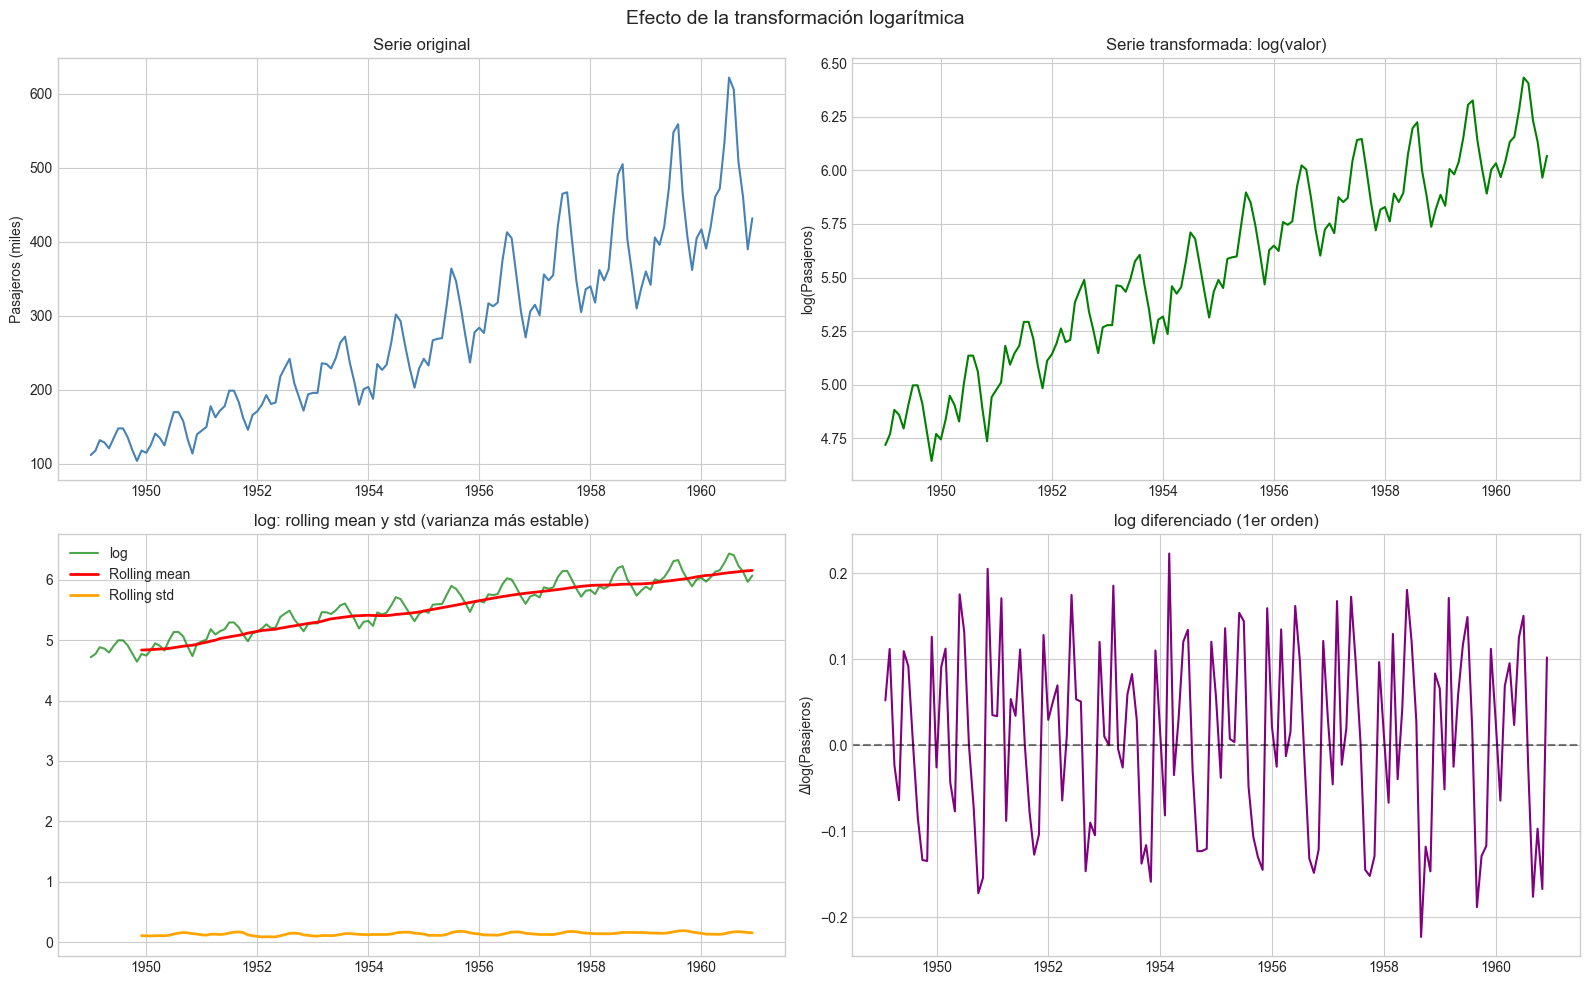


ADF — Log(AirPassengers)
  Estadístico ADF: -1.7170
  p-valor:         0.4224
  → No estacionaria ✗

ADF — Log diferenciado (1er orden)
  Estadístico ADF: -2.7171
  p-valor:         0.0711
  → No estacionaria ✗

Notas importantes:
• Log solo: la media sigue siendo creciente → aún NO estacionaria.
• Log + diff: media ~0 y varianza más constante → ESTACIONARIA ✓

Para el modelado ARIMA usaremos la serie log-transformada.
El parámetro d=1 del ARIMA aplicará la diferenciación automáticamente.

Para obtener predicciones en escala original: np.exp(predicciones)



In [26]:
# aplicamos logaritmo natural (np.log)
# para invertir: np.exp(log_value) devuelve el valor original
df['log_value'] = np.log(df['value'])

# visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# serie original
axes[0, 0].plot(df.index, df['value'], color='steelblue')
axes[0, 0].set_title('Serie original')
axes[0, 0].set_ylabel('Pasajeros (miles)')

# serie en log
axes[0, 1].plot(df.index, df['log_value'], color='green')
axes[0, 1].set_title('Serie transformada: log(valor)')
axes[0, 1].set_ylabel('log(Pasajeros)')

# log + Rolling mean/std para verificar estabilidad
log_rolling_mean = df['log_value'].rolling(12).mean()
log_rolling_std  = df['log_value'].rolling(12).std()
axes[1, 0].plot(df.index, df['log_value'], color='green', alpha=0.7, label='log')
axes[1, 0].plot(df.index, log_rolling_mean, color='red', linewidth=2, label='Rolling mean')
axes[1, 0].plot(df.index, log_rolling_std, color='orange', linewidth=2, label='Rolling std')
axes[1, 0].set_title('log: rolling mean y std (varianza más estable)')
axes[1, 0].legend()

# log diferenciado
log_diff = df['log_value'].diff(1)
axes[1, 1].plot(df.index, log_diff, color='purple')
axes[1, 1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title('log diferenciado (1er orden)')
axes[1, 1].set_ylabel('Δlog(Pasajeros)')

plt.suptitle('Efecto de la transformación logarítmica', fontsize=14)
plt.tight_layout()
plt.show()

# test ADF sobre la serie log-transformada
pval_log = test_adf(df['log_value'], 'Log(AirPassengers)')

# test ADF sobre log diferenciado
pval_logdiff = test_adf(df['log_value'].diff(1), 'Log diferenciado (1er orden)')

print("""
Notas importantes:
• Log solo: la media sigue siendo creciente → aún NO estacionaria.
• Log + diff: media ~0 y varianza más constante → ESTACIONARIA ✓

Para el modelado ARIMA usaremos la serie log-transformada.
El parámetro d=1 del ARIMA aplicará la diferenciación automáticamente.

Para obtener predicciones en escala original: np.exp(predicciones)
""")

## 5. Divide en train y test. Guarda 20 muestras para test.

In [ ]:
# en series temporales el split siempre es cronológico: train = datos más antiguos, test = datos más recientes
# # nunca se hace aleatoriamente, ya que el orden temporal es fundamental

Tamaño train: 124 muestras (1949-01-01 → 1959-04-01)
Tamaño test : 20 muestras (1959-05-01 → 1960-12-01)


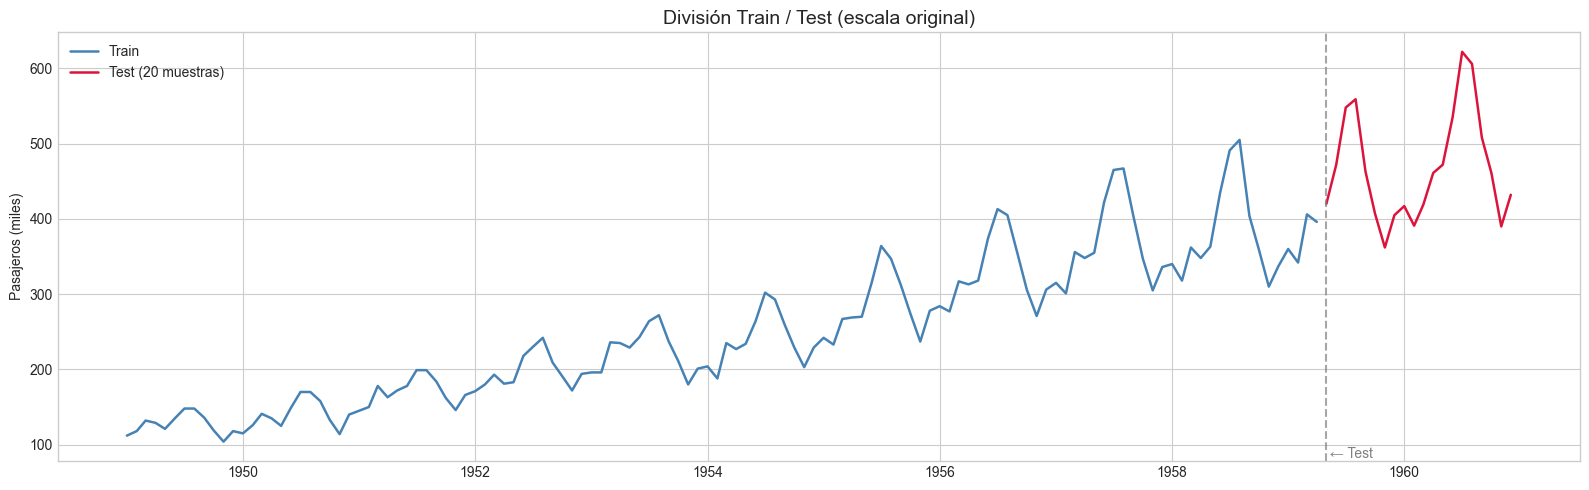

In [27]:
# trabajo con la serie log-transformada
serie_log = df['log_value']

# 20 muestras para test → las últimas 20 observaciones
n_test = 20
train = serie_log.iloc[:-n_test]
test  = serie_log.iloc[-n_test:]

# tmbn guardo los valores originales para invertir la transformación al evaluar
train_orig = df['value'].iloc[:-n_test]
test_orig  = df['value'].iloc[-n_test:]

print(f'Tamaño train: {len(train)} muestras ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Tamaño test : {len(test)} muestras ({test.index[0].date()} → {test.index[-1].date()})')

# visualización del split
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train.index, np.exp(train), color='steelblue', linewidth=1.8, label='Train')
ax.plot(test.index,  np.exp(test),  color='crimson',   linewidth=1.8, label='Test (20 muestras)')
ax.axvline(x=test.index[0], color='gray', linestyle='--', alpha=0.7)
ax.text(test.index[0], ax.get_ylim()[0]*1.05, ' ← Test', color='gray', fontsize=10)
ax.set_title('División Train / Test (escala original)', fontsize=14)
ax.set_ylabel('Pasajeros (miles)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Crea tu primer modelo ARIMA

In [ ]:
# ARIMA(p, d, q) combina tres componentes:
#   p: orden autoregresivo (cuántos lags pasados usamos)
#   d: grado de diferenciación para hacer estacionaria la serie
#   q: orden de media móvil (cuántos errores pasados usamos)

# SARIMA(p,d,q)(P,D,Q)[m] añade componentes estacionales con período m=12.

# usamos `auto_arima` para buscar automáticamente los mejores hiperparámetros.

In [28]:
# primer modelo: ARIMA sin estacionalidad
# este es un punto de partida básico para comparar
print('=== ARIMA básico (sin componente estacional) ===')
model_arima = ARIMA(order=(2, 1, 2))
model_arima.fit(train.values)

pred_arima_log = model_arima.predict(n_test)
pred_arima_orig = np.exp(pred_arima_log)  # invertimos la transformación logarítmica

mae_arima  = mean_absolute_error(test_orig, pred_arima_orig)
rmse_arima = np.sqrt(mean_squared_error(test_orig, pred_arima_orig))
print(f'  MAE  = {mae_arima:.2f} miles de pasajeros')
print(f'  RMSE = {rmse_arima:.2f} miles de pasajeros')
print()

=== ARIMA básico (sin componente estacional) ===
  MAE  = 66.89 miles de pasajeros
  RMSE = 77.11 miles de pasajeros



In [29]:
# auto ARIMA sin estacionalidad
# busca automáticamente la mejor combinación (p,d,q) minimizando el AIC
print('=== Auto ARIMA (sin estacionalidad) ===')
model_auto = auto_arima(
    train.values,
    start_p=1, start_q=1,
    max_p=5, max_q=5, max_d=2,
    stationary=False,
    trace=True,
    stepwise=True,
    suppress_warnings=True
)
print(f'\nMejor modelo sin estacionalidad: {model_auto.order}')
print(f'AIC: {model_auto.aic():.2f}')

pred_auto_log  = model_auto.predict(n_test)
pred_auto_orig = np.exp(pred_auto_log)
mae_auto  = mean_absolute_error(test_orig, pred_auto_orig)
rmse_auto = np.sqrt(mean_squared_error(test_orig, pred_auto_orig))
print(f'  MAE  = {mae_auto:.2f}')
print(f'  RMSE = {rmse_auto:.2f}')

=== Auto ARIMA (sin estacionalidad) ===
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-208.997, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-201.351, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-202.849, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-204.251, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-202.180, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-204.379, Time=0.07 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-225.739, Time=0.36 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-229.588, Time=0.47 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-229.000, Time=0.40 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-233.691, Time=0.48 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-214.822, Time=0.27 sec
 ARIMA(5

In [30]:
# SARIMA: Auto ARIMA CON estacionalidad
# al añadir m=12 incluimos un mini-ARIMA para la componente estacional
# SARIMA(p,d,q)(P,D,Q)[12]
print('=== Auto ARIMA CON estacionalidad (SARIMA, m=12) ===')
model_sarima = auto_arima(
    train.values,
    start_p=1, start_q=1,
    max_p=3, max_q=3, max_d=2,
    m=12, # Período estacional = 12 meses
    seasonal=True, # Activamos componente estacional
    D=1,  # Diferenciación estacional de orden 1
    trace=True,
    stepwise=True,
    suppress_warnings=True
)
print(f'\nMejor modelo SARIMA: ARIMA{model_sarima.order}x{model_sarima.seasonal_order}')
print(f'AIC: {model_sarima.aic():.2f}')

pred_sarima_log  = model_sarima.predict(n_test)
pred_sarima_orig = np.exp(pred_sarima_log)
mae_sarima  = mean_absolute_error(test_orig, pred_sarima_orig)
rmse_sarima = np.sqrt(mean_squared_error(test_orig, pred_sarima_orig))
print(f'  MAE  = {mae_sarima:.2f}')
print(f'  RMSE = {rmse_sarima:.2f}')

print(f"""
─────────────────────────────────────────────────────
Comparativa de modelos ARIMA:
  ARIMA básico (2,1,2)   → MAE={mae_arima:.1f}, RMSE={rmse_arima:.1f}
  Auto ARIMA (sin estac) → MAE={mae_auto:.1f},  RMSE={rmse_auto:.1f}
  SARIMA (m=12)          → MAE={mae_sarima:.1f},  RMSE={rmse_sarima:.1f}

→ El SARIMA debería dar el mejor resultado al capturar
  explícitamente la estacionalidad de 12 meses.
─────────────────────────────────────────────────────
""")

=== Auto ARIMA CON estacionalidad (SARIMA, m=12) ===
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=-409.584, Time=1.26 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-290.649, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-399.417, Time=1.17 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-353.179, Time=0.48 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-125.472, Time=0.01 sec
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=-411.631, Time=1.08 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=-384.170, Time=0.21 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=-409.714, Time=3.35 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=-405.268, Time=1.17 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=-408.108, Time=2.17 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=-408.087, Time=0.47 sec
 ARIMA(2,0,1)(0,1,1)[12] intercept   : AIC=-410.728, Time=1.04 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-409.956, Time=1.85 sec
 ARIMA(0,0,0)(0,1,1)[12] intercep

## 7. Representa en una gráfica los datos de test y tus predicciones.

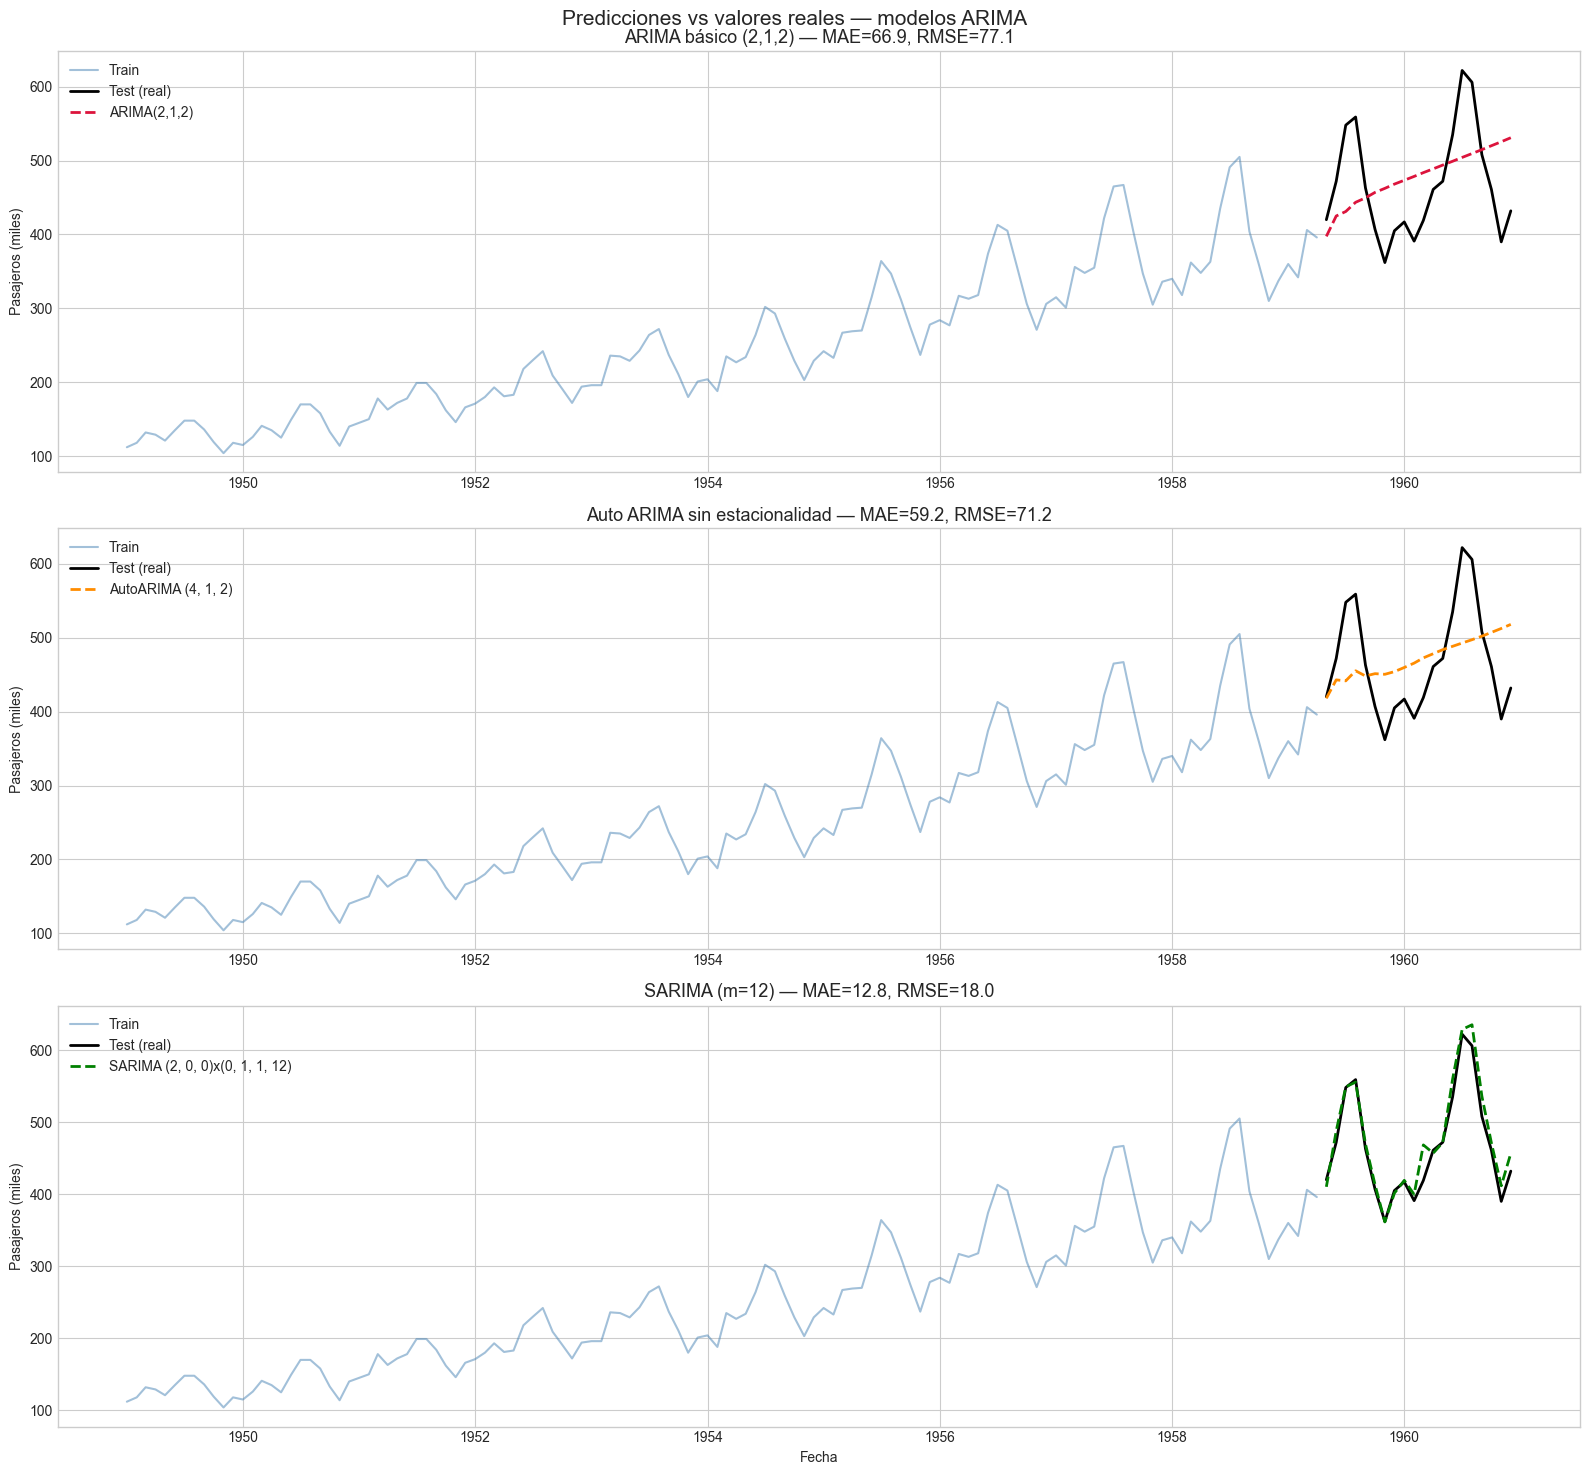

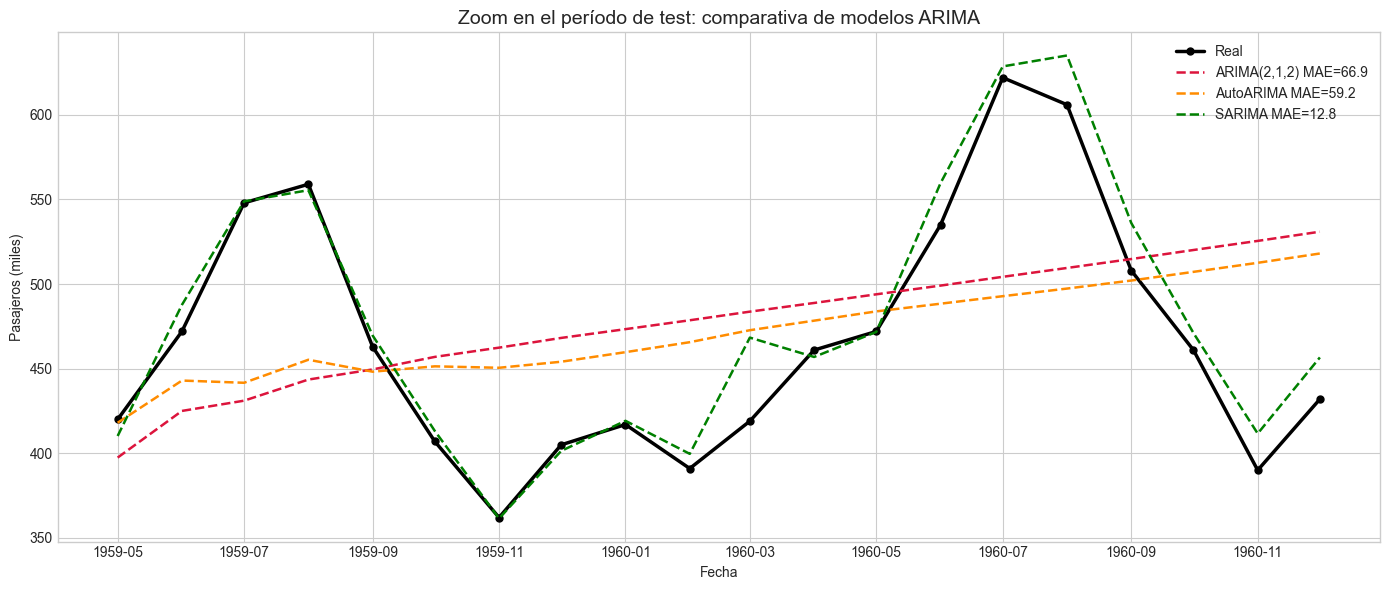

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

# eje x del test
test_dates = test_orig.index

# gráfica 1: ARIMA básico
axes[0].plot(train_orig.index, train_orig, color='steelblue', alpha=0.5, label='Train')
axes[0].plot(test_dates, test_orig,         color='black',    linewidth=2,   label='Test (real)')
axes[0].plot(test_dates, pred_arima_orig,   color='crimson',  linewidth=2,   label='ARIMA(2,1,2)', linestyle='--')
axes[0].set_title(f'ARIMA básico (2,1,2) — MAE={mae_arima:.1f}, RMSE={rmse_arima:.1f}', fontsize=13)
axes[0].legend()
axes[0].set_ylabel('Pasajeros (miles)')

# gráfica 2: Auto ARIMA sin estacionalidad
axes[1].plot(train_orig.index, train_orig, color='steelblue', alpha=0.5, label='Train')
axes[1].plot(test_dates, test_orig,         color='black',    linewidth=2,   label='Test (real)')
axes[1].plot(test_dates, pred_auto_orig,    color='darkorange', linewidth=2, label=f'AutoARIMA {model_auto.order}', linestyle='--')
axes[1].set_title(f'Auto ARIMA sin estacionalidad — MAE={mae_auto:.1f}, RMSE={rmse_auto:.1f}', fontsize=13)
axes[1].legend()
axes[1].set_ylabel('Pasajeros (miles)')

# ── Gráfica 3: SARIMA ─────────────────────────────────────────────────────────
axes[2].plot(train_orig.index, train_orig, color='steelblue', alpha=0.5, label='Train')
axes[2].plot(test_dates, test_orig,         color='black',    linewidth=2,   label='Test (real)')
axes[2].plot(test_dates, pred_sarima_orig,  color='green',    linewidth=2,   label=f'SARIMA {model_sarima.order}x{model_sarima.seasonal_order}', linestyle='--')
axes[2].set_title(f'SARIMA (m=12) — MAE={mae_sarima:.1f}, RMSE={rmse_sarima:.1f}', fontsize=13)
axes[2].legend()
axes[2].set_ylabel('Pasajeros (miles)')
axes[2].set_xlabel('Fecha')

plt.suptitle('Predicciones vs valores reales — modelos ARIMA', fontsize=15)
plt.tight_layout()
plt.show()

# ── Gráfica de comparativa centrada solo en el periodo de test ────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, test_orig,        color='black',      linewidth=2.5, label='Real', marker='o', markersize=5)
ax.plot(test_dates, pred_arima_orig,  color='crimson',    linewidth=1.8, label=f'ARIMA(2,1,2) MAE={mae_arima:.1f}',  linestyle='--')
ax.plot(test_dates, pred_auto_orig,   color='darkorange', linewidth=1.8, label=f'AutoARIMA MAE={mae_auto:.1f}',       linestyle='--')
ax.plot(test_dates, pred_sarima_orig, color='green',      linewidth=1.8, label=f'SARIMA MAE={mae_sarima:.1f}',        linestyle='--')
ax.set_title('Zoom en el período de test: comparativa de modelos ARIMA', fontsize=14)
ax.set_ylabel('Pasajeros (miles)')
ax.set_xlabel('Fecha')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Prueba otros modelos supervisados, a ver qué performance presentan.

In [ ]:
# para usar modelos de ML supervisado con series temporales hay que **reformular el problema**: crear features con los lags pasados para que el modelo pueda "ver" el contexto temporal.

# estrategia:
#   crear columnas de lags (t-1, t-2, ..., t-12).
#   usar esas columnas como X y el valor actual como y.
#   dividir cronológicamente en train/test.
#   hacer predicciones de forma iterativa (un paso a la vez).

In [32]:
# preparación de datos tabulares con lags
# usamos la serie log-transformada para homogeneizar con los modelos ARIMA
n_lags = 12  # Usamos 12 lags para capturar el patrón estacional completo

df_ml = pd.DataFrame({'y': serie_log})

# creamos una columna por cada lag
for i in range(1, n_lags + 1):
    df_ml[f't-{i}'] = df_ml['y'].shift(i)

# eliminamos filas con NaN (los primeros n_lags registros)
df_ml.dropna(inplace=True)

print(f'Shape del DataFrame tabular: {df_ml.shape}')
display(df_ml.head(3))

# split cronológico
# misma lógica: últimas 20 filas = test
X = df_ml.drop('y', axis=1).values
y = df_ml['y'].values

X_train, X_test = X[:-n_test], X[-n_test:]
y_train, y_test = y[:-n_test], y[-n_test:]

# índices de fechas del test para las gráficas
test_dates_ml = df_ml.index[-n_test:]
y_test_orig   = np.exp(y_test)  # valores reales en escala original

print(f'\nTrain: {len(X_train)} muestras | Test: {len(X_test)} muestras')

Shape del DataFrame tabular: (132, 13)


,y,t-1,t-2,t-3,t-4,t-5,t-6,t-7,t-8,t-9,t-10,t-11,t-12
date,,,,,,,,,,,,,
1950-01-01,4.744932,4.770685,4.644391,4.779123,4.912655,4.997212,4.997212,4.905275,4.795791,4.859812,4.882802,4.770685,4.718499
1950-02-01,4.836282,4.744932,4.770685,4.644391,4.779123,4.912655,4.997212,4.997212,4.905275,4.795791,4.859812,4.882802,4.770685
1950-03-01,4.948760,4.836282,4.744932,4.770685,4.644391,4.779123,4.912655,4.997212,4.997212,4.905275,4.795791,4.859812,4.882802



Train: 112 muestras | Test: 20 muestras


In [33]:
# decision Tree Regressor
# los árboles de decisión aprenden reglas if-else sobre los lags.
# max_depth limita la profundidad para evitar overfitting.
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

pred_dt_log  = dt.predict(X_test)
pred_dt_orig = np.exp(pred_dt_log)
mae_dt  = mean_absolute_error(y_test_orig, pred_dt_orig)
rmse_dt = np.sqrt(mean_squared_error(y_test_orig, pred_dt_orig))

print('=== Decision Tree Regressor (max_depth=5) ===')
print(f'  MAE  = {mae_dt:.2f}')
print(f'  RMSE = {rmse_dt:.2f}')

# ── Random Forest Regressor ───────────────────────────────────────────────────
# Ensemble de árboles que promedia las predicciones → más robusto y menos
# propenso a overfitting que un árbol solitario.
rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred_rf_log  = rf.predict(X_test)
pred_rf_orig = np.exp(pred_rf_log)
mae_rf  = mean_absolute_error(y_test_orig, pred_rf_orig)
rmse_rf = np.sqrt(mean_squared_error(y_test_orig, pred_rf_orig))

print()
print('=== Random Forest Regressor (200 árboles, max_depth=5) ===')
print(f'  MAE  = {mae_rf:.2f}')
print(f'  RMSE = {rmse_rf:.2f}')

=== Decision Tree Regressor (max_depth=5) ===
  MAE  = 37.83
  RMSE = 50.25

=== Random Forest Regressor (200 árboles, max_depth=5) ===
  MAE  = 37.86
  RMSE = 54.60


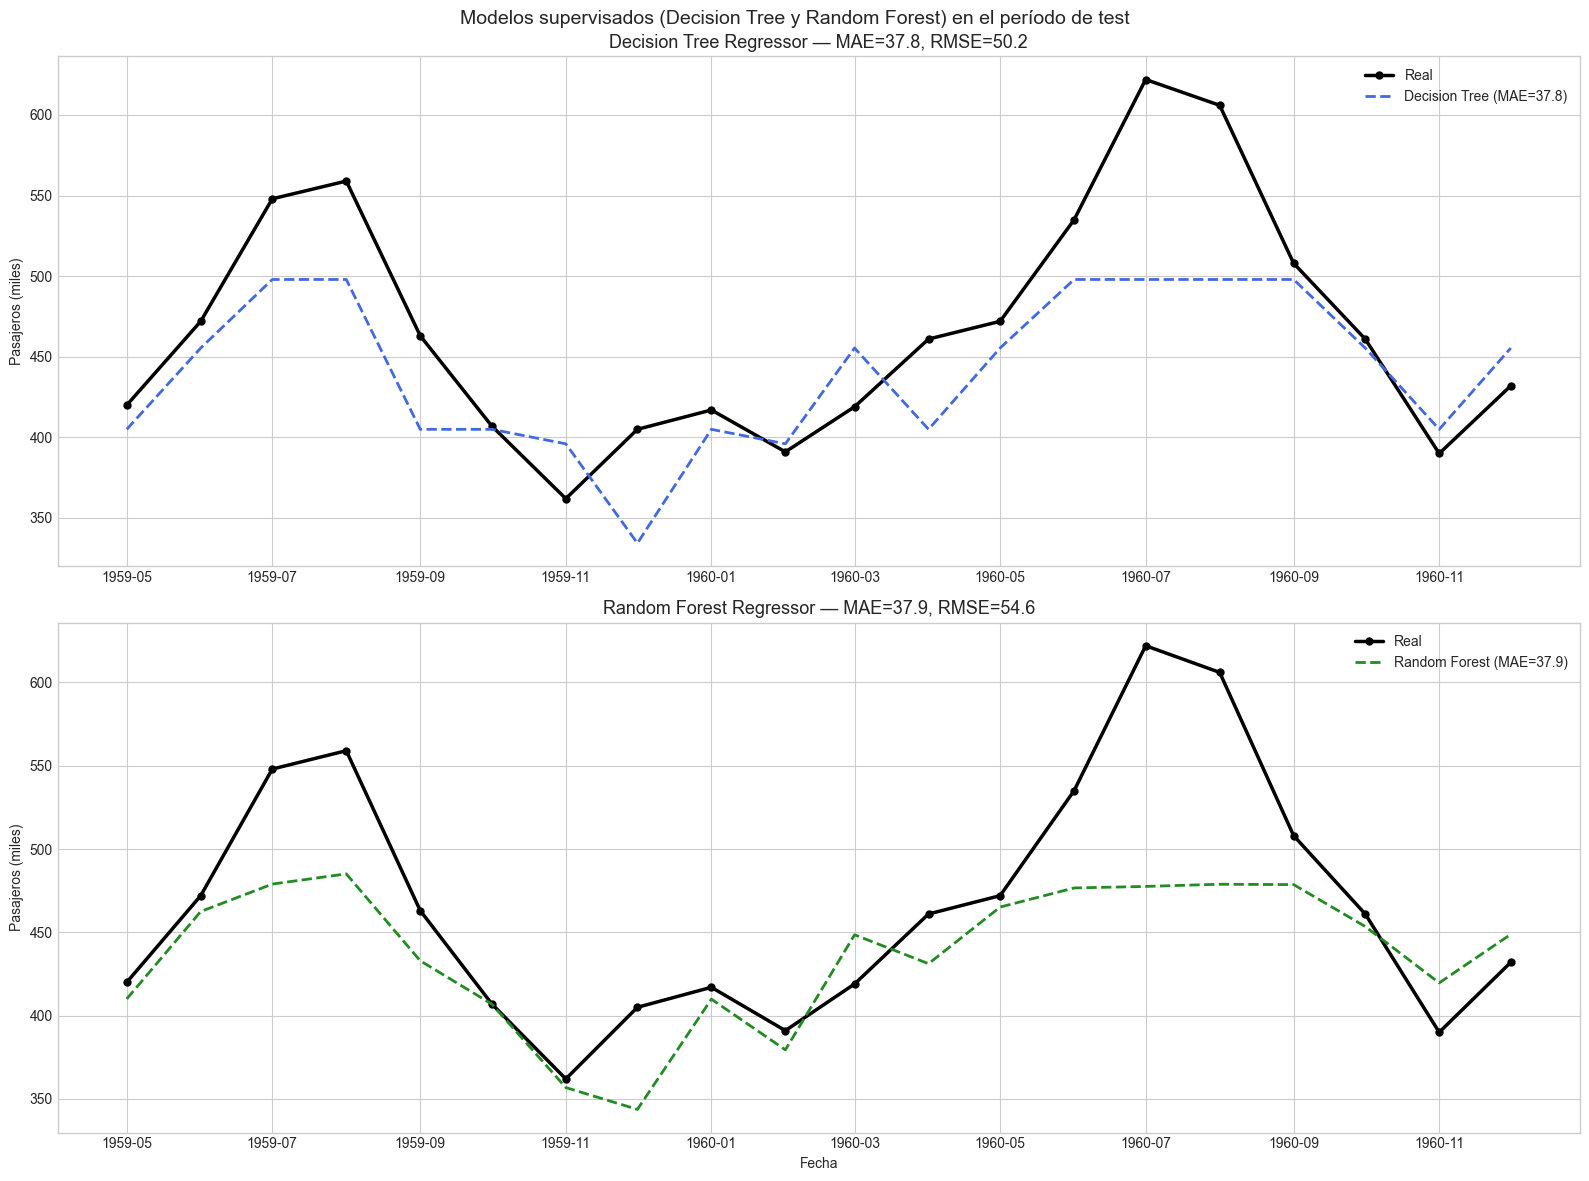

In [34]:
# visualización comparativa de todos los modelos
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# decision Tree
axes[0].plot(test_dates_ml, y_test_orig,   color='black',    linewidth=2.5, label='Real', marker='o', markersize=5)
axes[0].plot(test_dates_ml, pred_dt_orig,  color='royalblue',linewidth=2,   label=f'Decision Tree (MAE={mae_dt:.1f})', linestyle='--')
axes[0].set_title(f'Decision Tree Regressor — MAE={mae_dt:.1f}, RMSE={rmse_dt:.1f}', fontsize=13)
axes[0].legend()
axes[0].set_ylabel('Pasajeros (miles)')

# random forest
axes[1].plot(test_dates_ml, y_test_orig,   color='black',    linewidth=2.5, label='Real', marker='o', markersize=5)
axes[1].plot(test_dates_ml, pred_rf_orig,  color='forestgreen', linewidth=2, label=f'Random Forest (MAE={mae_rf:.1f})', linestyle='--')
axes[1].set_title(f'Random Forest Regressor — MAE={mae_rf:.1f}, RMSE={rmse_rf:.1f}', fontsize=13)
axes[1].legend()
axes[1].set_ylabel('Pasajeros (miles)')
axes[1].set_xlabel('Fecha')

plt.suptitle('Modelos supervisados (Decision Tree y Random Forest) en el período de test', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
# tabla resumen final de todos los modelos
resultados = pd.DataFrame({
    'Modelo': [
        'ARIMA(2,1,2)',
        f'AutoARIMA {model_auto.order}',
        f'SARIMA {model_sarima.order}x{model_sarima.seasonal_order}',
        'Decision Tree (depth=5)',
        'Random Forest (200 trees)'
    ],
    'MAE':  [mae_arima, mae_auto, mae_sarima, mae_dt, mae_rf],
    'RMSE': [rmse_arima, rmse_auto, rmse_sarima, rmse_dt, rmse_rf]
})
resultados = resultados.sort_values('MAE').reset_index(drop=True)
resultados['MAE']  = resultados['MAE'].round(2)
resultados['RMSE'] = resultados['RMSE'].round(2)

print('\n' + '='*60)
print('       TABLA RESUMEN — COMPARATIVA DE MODELOS')
print('='*60)
print(resultados.to_string(index=False))
print('='*60)

print(f"""
Conclusiones finales:
─────────────────────────────────────────────────────────────
• SARIMA: mejor modelo para esta serie porque captura
  explícitamente la estacionalidad (parámetro m=12) y la
  tendencia mediante diferenciación (d y D).

• Random Forest: puede obtener buenos resultados si los lags
  están bien diseñados (aquí usamos 12 lags). Es más flexible
  que el árbol individual y menos propenso a overfitting.

• Decision Tree: tiende a overfittear en series cortas.
  Con max_depth pequeño puede ser razonable.

• Los modelos de ML necesitan feature engineering manual
  (crear lags), mientras que ARIMA/SARIMA lo hace de forma
  implícita en su formulación matemática.

• Para producción: SARIMA + validación walk-forward (ampliar
  train de forma incremental) sería la estrategia óptima.
─────────────────────────────────────────────────────────────
""")


       TABLA RESUMEN — COMPARATIVA DE MODELOS
                        Modelo   MAE  RMSE
SARIMA (2, 0, 0)x(0, 1, 1, 12) 12.82 17.96
       Decision Tree (depth=5) 37.83 50.25
     Random Forest (200 trees) 37.86 54.60
           AutoARIMA (4, 1, 2) 59.17 71.18
                  ARIMA(2,1,2) 66.89 77.11

Conclusiones finales:
─────────────────────────────────────────────────────────────
• SARIMA: mejor modelo para esta serie porque captura
  explícitamente la estacionalidad (parámetro m=12) y la
  tendencia mediante diferenciación (d y D).

• Random Forest: puede obtener buenos resultados si los lags
  están bien diseñados (aquí usamos 12 lags). Es más flexible
  que el árbol individual y menos propenso a overfitting.

• Decision Tree: tiende a overfittear en series cortas.
  Con max_depth pequeño puede ser razonable.

• Los modelos de ML necesitan feature engineering manual
  (crear lags), mientras que ARIMA/SARIMA lo hace de forma
  implícita en su formulación matemática.

• Para pro

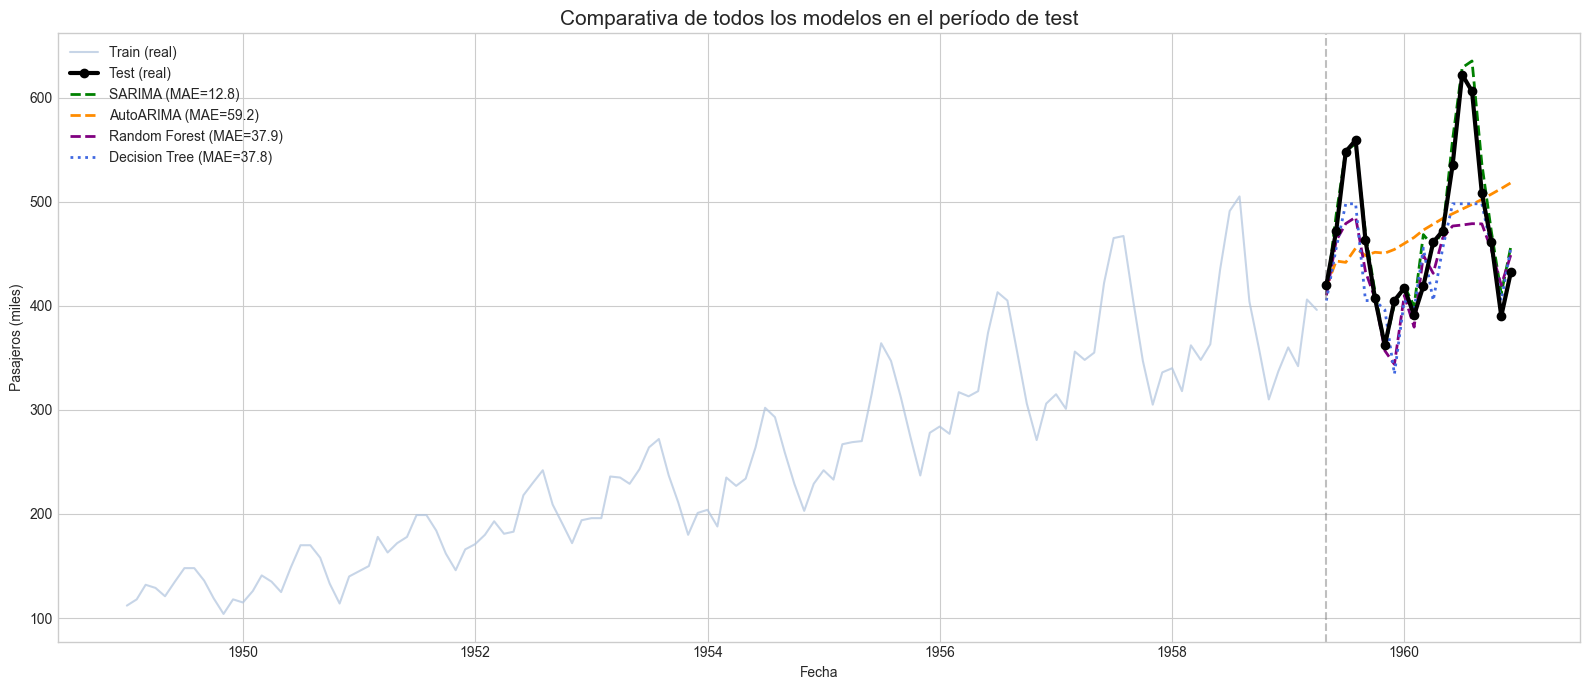

In [36]:
# gráfica final: todos los modelos juntos
fig, ax = plt.subplots(figsize=(16, 7))

# datos completos
ax.plot(df.index[:-n_test], df['value'].iloc[:-n_test],
        color='lightsteelblue', linewidth=1.5, label='Train (real)', alpha=0.7)

# test real
ax.plot(test_dates_ml, y_test_orig,
        color='black', linewidth=3, label='Test (real)', marker='o', markersize=6, zorder=5)

# predicciones
ax.plot(test_dates_ml, pred_sarima_orig, color='green',      linewidth=2, linestyle='--', label=f'SARIMA (MAE={mae_sarima:.1f})')
ax.plot(test_dates_ml, pred_auto_orig,   color='darkorange', linewidth=2, linestyle='--', label=f'AutoARIMA (MAE={mae_auto:.1f})')
ax.plot(test_dates_ml, pred_rf_orig,     color='purple',     linewidth=2, linestyle='--', label=f'Random Forest (MAE={mae_rf:.1f})')
ax.plot(test_dates_ml, pred_dt_orig,     color='royalblue',  linewidth=2, linestyle=':',  label=f'Decision Tree (MAE={mae_dt:.1f})')

ax.axvline(x=test_dates_ml[0], color='gray', linestyle='--', alpha=0.5)
ax.set_title('Comparativa de todos los modelos en el período de test', fontsize=15)
ax.set_ylabel('Pasajeros (miles)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()